#**Case 2026.2**

##Introdução

Os membros da diretoria do Hype, de tempos em tempos, organizam um pequeno evento interno chamado Hype League. Durante esse período, os membros da entidade se reúnem para algumas horas de jogatina coletiva.

Uma das partes mais aguardadas do Hype League é a escolha dos jogos que serão jogados durante o evento. Alguns preferem jogos competitivos, outros preferem jogos cooperativos, enquanto alguns apenas querem algo divertido para passar o tempo entre uma conversa e outra.

Para a próxima edição do Hype League, os membros da diretoria decidiram fazer um levantamento maior de jogos que poderiam aparecer durante o evento. Porém, rapidamente surgiu algumas dúvidas: quais jogos realmente gerariam mais Hype para cada perfil dentro do Hype?

Cada setor da entidade (Acadêmico, Eventos, Comunicações e Gestão de Pessoas) decidiu montar sua própria seleção de jogos, baseada no que acreditavam ser as melhores opções para o evento. No entanto, ficou evidente que os critérios utilizados por cada setor não estavam totalmente claros.

Durante uma conversa sobre o assunto, alguém lembrou que, alguns anos atrás, um antigo membro da entidade havia **convenientemente** montado um grande conjunto de dados com informações sobre diversos jogos. Além das características dos jogos, esse conjunto de dados também incluía uma variável indicando a qual setor do Hype aquele jogo estaria mais associado, com base em seu perfil.

##Instruções

O case tem como objetivo verificar se o candidato tem conhecimento suficiente para fazer um projeto de classificação de dados utilizando análise exploratória e algoritmos de Machine Learning. O notebook abaixo dá as instruções do que deve ser feito em cada etapa do projeto.

Pode mexer nas colunas do dataset o quanto achar necessário (inclusive excluir colunas inteiras), desde que cada alteração seja justificada. Observações quanto a limitações e outras coisas relacionadas ao dataset são muito bem-vindas durante a resolução das etapas do case.

Você deve escrever seus códigos nas células indicadas. Pode inserir quantas células achar necessário, mas não altere a ordem das resoluções.

Além da corretude, será avaliado também a organização e a lógica utilizada. O candidato deve deixar claro os motivos das escolhas que fizer no projeto (por que aplicou algum tratamento, algoritmo ou por que utilizou determinadas variáveis).

Entregas incompletas também serão aceitas. Os avaliadores irão analisar cada situação, então se não conseguir fazer tudo recomendamos que submeta o case mesmo assim.

### Sua tarefa para esse case

Sua tarefa consiste em entender o conjunto de dados e criar um classificador que consiga indicar qual setor do Hype teria maior afinidade com um determinado jogo.

Para isso, seu trabalho será dividido em 5 tarefas:

1. "Responda as questões"
responda algumas perguntas de análise preliminar sobre o conjunto de dados utilizando pandas e numpy.

2. "Visualização dos dados"
crie gráficos que respondam algumas questões sobre o conjunto de dados.

3. "Preparação de dados"
faça a limpeza e preparação dos dados; testar métodos de normalização e padronização, conforme necessário. Além disso, deve discutir e/ou abordar o tratamento de dados ausentes e duplicados.

4. "Aplicação e otimização do modelo"
crie um classificador que consiga indicar, com base nas características de um jogo, qual setor do Hype teria maior afinidade com ele.

Detalhe o processo de treinamento, incluindo:

- escolha do modelo
- preparação dos dados para treino
- divisão entre treino e teste

5. "Avaliação"
avalie o classificador criado, utilizando diferentes métricas de avaliação. A interpretação dos resultados deve ser clara, permitindo compreender o desempenho do modelo.

**Observações**
- Não existe uma única resposta correta
- Suas decisões são tão importantes quanto seus resultados
- Nem toda análise leva a um resultado forte ou conclusivo, saber identificar e comunicar isso também é parte da avaliação
- Clareza, organização e justificativas serão avaliadas

Mais detalhes das tarefas estão no decorrer do notebook.

### Sobre o Conjunto de Dados

O dataset possui informações sobre diversos jogos lançados ao longo dos anos. Entre as colunas disponíveis estão:

- Name: nome do jogo

- Platform: plataforma em que o jogo foi lançado

- Year_of_Release: ano de lançamento

- Genre: gênero do jogo

- Publisher: empresa responsável pela publicação do jogo

- Developer: empresa responsável pelo desenvolvimento do jogo

- Global_Sales: vendas globais do jogo (em milhões)

- Critic_Score: avaliação da crítica especializada

- Critic_Count: numero de avaliações da crítica

- User_Score: avaliação média dos usuários

- User_Count: numero de avaliações dos usuários

- Rating: classificação indicativa

- Sales_Category: Categoria de vendas (baixo, médio, alto)

- Setor: setor do Hype que possivelmente teria maior interesse naquele jogo

##Setup

Antes de iniciar as tarefas, vamos setar algumas coisas.

Na célula abaixo, importe todas as bibliotecas que você utilizará no case. Não faça imports fora além dessa célula.

In [1]:
# coloque aqui os seus import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

Abaixo há a leitura do conjunto de dados. Não leia nenhum conjunto de dados além desse e adicione a forma de leitura do dataset que preferir.

In [2]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
# leitura do dataset
# sugestão: games = pd.read_csv('dataset/games_hype_v2.csv')
games = pd.read_csv('/content/drive/MyDrive/Datasets/games_hype_v2.csv')

# visualização das 5 primeiras linhas
games.head()

,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Sales_Category,Setor
0,Wall-E,Wii,2008,Platform,THQ,1.01,51.0,18.0,3.6,8.0,Heavy Iron Studios,E,High,GP
1,Naruto: Clash of Ninja Revolution,Wii,2007,Fighting,Tomy Corporation,1.01,74.0,23.0,8.0,27.0,8ing/Raizing,T,High,Eventos
2,Disney Fairies: Tinker Bell and the Lost Treasure,DS,2009,Adventure,Disney Interactive Studios,1.01,71.0,0.0,7.5,0.0,Hyde,E,High,Comunicacoes
3,Ace Combat 6: Fires of Liberation,X360,2007,Simulation,Atari,1.01,80.0,54.0,7.9,101.0,Project Aces,T,High,Comunicacoes
4,The Simpsons Game,Wii,2007,Action,Electronic Arts,1.01,64.0,19.0,6.1,38.0,"Electronic Arts, Rebellion",T,High,Comunicacoes


##Tarefas

Abaixo, em cada seção, realize as tarefas. Boa sorte!!!

### **Seção 1: Respondas as questões**

Com base no conjunto de dados, responda as perguntas abaixo utilizando Pandas ou Numpy para obter os resultados. Coloque seu código na célula marcada com "### Seu código" e sua resposta após o "Resposta".

Fique a vontade para criar mais células para o seu código caso ache necessário.

O item "a" é um exemplo de resposta

#### a. Qual a proporção de jogos em cada setor? (Exemplo)

In [4]:
### Exemplo de resposta:
proporcao_setor = games['Setor'].value_counts(normalize=True)
proporcao_setor

,proportion
Setor,
Academico,0.279882
Comunicacoes,0.257218
GP,0.233934
Eventos,0.228966


Resposta:

Academico, Aproximadamente 28%

Comunicacoes, Aproximadamente 26%

GP, Aproximadamente 23%

Eventos, Aproximadamente 23%

#### b. Dentre os jogos lançados a partir de 2010 e que possuem Critic_Score acima da média do dataset, qual jogo possui o maior User_Count?

In [5]:
media_b = games['Critic_Score'].mean()
media_b
df_b = games[(games['Year_of_Release']>=2010) & (games['Critic_Score']>media_b)].copy()
resposta_b = df_b.loc[df_b['User_Count'].idxmax()]
resposta_b

,678
Name,The Witcher 3: Wild Hunt
Platform,PC
Year_of_Release,2015
Genre,Role-Playing
Publisher,namco bandai games
Global_Sales,0.72
Critic_Score,93.0
Critic_Count,32.0
User_Score,9.3
User_Count,10665.0


Resposta: O jogo que possui a maior número de avaliações pelos usuários é o "The Witcher 3: Wild Hunt"

#### c. Considerando apenas jogos que:

- possuem User_Score acima da mediana
- pertencem a gêneros diferentes do gênero mais frequente no dataset

qual plataforma apresenta a maior média de Critic_Score?

In [6]:
#Começo do exercício que me fez ver o problema
#mediana_c_User_Score = games['User_Score'].median()
#mediana_c_User_Score
#moda_c_Genre = games['Genre'].mode()[0]
#moda_c_Genre
#df_c = games[(games['User_Score']>mediana_c_User_Score) & (games['Genre'] != moda_c_Genre)]
#teste_genero = df_c.groupby('Genre')['Critic_Score'].mean()
#teste_genero

#vendo as diferentes representações de variaveis no dataset
print(repr(games['Platform'].unique()))
print('\n\n')
print(repr(games['Genre'].unique()))

array(['Wii', 'DS', 'X360', 'PC', 'PSV', 'PS4', 'WiiU', 'PS2', 'PSP',
       'N64', 'XB', 'PS', 'PS3', 'GC', 'ds', 'GBA', '3DS', 'wii', 'XOne',
       'PS2 ', 'X360 ', 'GB', 'WII', 'PS3 ', '3DS ', 'gc', ' PS3 ', 'ps4',
       'DS ', ' Wii ', ' GBA ', ' PC ', 'XOn3', 'psp', ' PS2 ', 'PS ',
       'gba', 'GBA ', 'WS', 'ps3', 'x360', 'ps2', 'psv', ' PS4 ', ' DS ',
       'Wii ', ' XB ', 'xb', 'XB ', 'DC', ' PSP ', 'pc', ' X360 ', ' GC ',
       ' 3DS ', 'wiiu', 'XONE', 'PSP ', ' PS ', ' PSV ', '3ds', 'GC ',
       ' WiiU ', 'ps', 'xone', 'PS4 ', ' XOne ', 'PC '], dtype=object)



array(['Platform', 'Fighting', 'Adventure', 'Simulation', 'Action',
       'Sports', 'Racing', 'Misc', 'Shooter', 'action', 'Role-Playing',
       'Puzzle', 'Strategy', 'SHOOTER', ' Action ', 'Adv3ntur3', ' Misc ',
       'ACTION', 'fighting', 'platform', 'simulation', 'SPORTS', 'racing',
       'Rol3-Playing', 'Sports ', 'FIGHTING', 'RACING', 'ROLE-PLAYING',
       'Action ', 'sports', ' Adventure ', 'MISC', ' R

Nessa parte foi possível identificar um problema do Dataset, alguns nomes de plataformas não estão padronizados, fazendo eles aparecerem mais de uma vez no ".groupby" como foi o caso da plataforma "PC" que apareceu 4 vezes

Isso inclusive me fez duvidar se a filtragem booleana dos dados estava realmente satisfatória, por isso fiz mais alguns teste e percebi que esse problema do tratamento dos dados influenciou no funcionamento do filtro também. Gerando resultados incorretos

Para contornar esse problema, tive que fazer um tratamento dos dados que serão utilizados

*OBS: Não duvidei da corretude do exercício anterior por serem dados numéricos, ou seja, não possuem esse problema de diferentes digitações

In [7]:
#tratamento dos dados da coluna do genero do jogo
games['Genre'] = games['Genre'].str.lower()
games['Genre'] = games['Genre'].str.strip()
games['Genre'] = games['Genre'].str.replace('3', 'e') #no caso dessa coluna precisamos desse ".replace"
#tratamento da coluna de plataforma
games['Platform'] = games['Platform'].str.lower()
games['Platform'] = games['Platform'].str.strip()
games['Platform'] = games['Platform'].str.replace('xon3', 'xone')
#teste para ver se a variaveis foram alteradas
print(repr(games['Platform'].unique()))
print('\n\n')
print(repr(games['Genre'].unique()))

array(['wii', 'ds', 'x360', 'pc', 'psv', 'ps4', 'wiiu', 'ps2', 'psp',
       'n64', 'xb', 'ps', 'ps3', 'gc', 'gba', '3ds', 'xone', 'gb', 'ws',
       'dc'], dtype=object)



array(['platform', 'fighting', 'adventure', 'simulation', 'action',
       'sports', 'racing', 'misc', 'shooter', 'role-playing', 'puzzle',
       'strategy'], dtype=object)


Depois de tratado o problema dos dados, voltamos a resolver a questão

In [8]:
#voltando para a resolução da questão
mediana_c_User_Score = games['User_Score'].median()
moda_c_Genre = games['Genre'].mode()[0]
df_c = games[(games['User_Score']>mediana_c_User_Score) & (games['Genre'] != moda_c_Genre)].copy()
df_c.groupby('Platform')['Critic_Score'].mean()

,Critic_Score
Platform,
3ds,77.189189
dc,85.800000
ds,73.666667
gba,74.936937
gc,75.756579
pc,80.269231
ps,75.200000
ps2,71.551111
ps3,78.425926


Resposta: A plataforma que possui a maior média da nota da crítica é o dc (dreamcast)

#### d. Entre os jogos classificados como Sales_Category = High:

Qual possui a maior diferença absoluta entre Critic_Score e User_Score?

O que isso pode indicar sobre a recepção do jogo?

In [9]:
df_d = games[games['Sales_Category'] == 'High'].copy()
df_d['dif'] = abs (df_d['Critic_Score'] - df_d['User_Score'])
resposta_d_1 = df_d.loc[df_d['dif'].idxmax()]
df_d['Critic_Score'] = df_d['Critic_Score'] / 10
df_d['dif'] = abs (df_d['Critic_Score'] - df_d['User_Score'])
resposta_d_2 = df_d.loc[df_d['dif'].idxmax()]
df_d = df_d[df_d['Critic_Count'] != 0]
df_d = df_d[df_d['User_Count'] != 0]
resposta_d_3 = df_d.loc[df_d['dif'].idxmax()]
print(resposta_d_1)
print('\n')
print(resposta_d_2)
print('\n')
print(resposta_d_3)

Name               Metal Gear Solid V: The Phantom Pain
Platform                                           xone
Year_of_Release                                    2015
Genre                                            action
Publisher                  Konami Digital Entertainment
Global_Sales                                       0.75
Critic_Score                                       95.0
Critic_Count                                       10.0
User_Score                                          7.3
User_Count                                        900.0
Developer          Kojima Productions, Moby Dick Studio
Rating                                                M
Sales_Category                                     High
Setor                                         Academico
dif                                                87.7
Name: 562, dtype: object


Name               My Little Pony: Pinkie Pie's Party
Platform                                           ds
Year_of_Release          

Resposta: Se formos fazer **apenas a diferença absoluta** teremos que o a resposta seria **"Metal Gear Solid V: The Phantom Pain"**, porém isso se dá pela nota alta da crítica, que é uma nota de 0 a 100, ou seja tem um peso 10 vezes maior que a dos usuários, que quando subtraída pela nota dos usuários, que vai de 0 a 10, gera uma diferença grande, porém não por uma disparidade grande entre ideia da crítica sobre o jogo e a recepção pelos usuários, mas pela nota alta da crítica. Para termos uma comparação mais igual e equilibrada devemos **igualar o intervalo da nota**, para isso dividimos a nota da crítica por 10. Com isso temos que o jogo com a maior disparidade é **"My Little Pony: Pinkie Pie's Party"**, que, nesse caso, sim podemos comparar, porém temos um problema, pois a nota de crítica é 7.1, mas não há nenhuma avaliação da crítica, criando um **dado que não faz sentido**, como temos uma nota da crítica sem termos avaliações dela? Logo, a **melhor resposta**, na minha opinião, para o jogo com a maior diferença absoluta é **"Shrek Swamp Kart Speedway"**, já que **não há essas inconsistências e as notas estão no mesmo peso**. As **conclusões** que tiramos desse valor é o indicador de que a recepção do público com o jogo foi bem diferente do que a análise e nota mais técnica e minuciosa da crítica indicaria, nesse caso foi mais positiva que o imaginado, e isso pode ser explicado por fatores como um jogo ser divertido e engraçado de jogar, seja pelos personagens, ou como no caso de um jogo brasileiro "mineirinho" por ser tão ruim que chega a ser engraçado, mas possuir uma parte técnica como, por exemplo, jogabilidade péssima, que faz a nota da crítica ser baixa

#### e. Para cada setor do Hype:

- Qual é o gênero mais frequente?
- Qual é a média de User_Score?
- Qual setor possui jogos com maior engajamento (média de User_Count)?

In [10]:
print(games.groupby('Setor')['Genre'].value_counts())
print('\n')
print(games.groupby('Setor')['User_Score'].mean())
print('\n')
print(games.groupby('Setor')['User_Count'].mean())

Setor         Genre       
Academico     role-playing     604
              action           575
              sports           428
              misc             400
              adventure        342
              strategy         268
              puzzle           209
              shooter          187
              racing           184
              simulation       154
              platform         135
              fighting         120
Comunicacoes  action          1233
              adventure        425
              simulation       309
              sports           304
              misc             232
              role-playing     180
              shooter          174
              racing           134
              platform          98
              fighting          96
              strategy          69
              puzzle            60
Eventos       sports           753
              action           414
              racing           410
              misc          

Resposta: Para cada setor do Hype temos:

*   Acadêmico:

    * Gênero mais frequente: Role-Playing
    * Média das notas dos usuários: 7.41
    * Média de quantidade de avaliações de usuários: 54.01

*   Comunicações:

    * Gênero mais frequente: Ação
    * Média das notas dos usuários: 7.19
    * Média de quantidade de avaliações de usuários: 50.58

*   Eventos:

    * Gênero mais frequente: Esporte
    * Média das notas dos usuários: 7.30
    * Média de quantidade de avaliações de usuários: 34.41

*   GP:

    * Gênero mais frequente: Outros
    * Média das notas dos usuários: 7.07
    * Média de quantidade de avaliações de usuários: 41.32

Logo, **o setor que possui jogos com com maior engajamento é o Academico**

#### f. Dentre os jogos que:

- não pertencem ao gênero mais comum do dataset
- foram lançados antes de 2015
- possuem User_Count acima da mediana

Qual jogo apresenta a maior Global_Sales?

In [11]:
df_f = games[(games['Genre'] != games['Genre'].mode()[0]) & (games['Year_of_Release'] < 2015) & (games['User_Count'] > games['User_Count'].median())].copy()
df_f.sample(10)
df_f.loc[df_f['Global_Sales'].idxmax()]

,0
Name,Wall-E
Platform,wii
Year_of_Release,2008
Genre,platform
Publisher,THQ
Global_Sales,1.01
Critic_Score,51.0
Critic_Count,18.0
User_Score,3.6
User_Count,8.0


Resposta: O jogo que apresenta maior global sales é "Wall-E"

#### g. Existe relação entre o ano de lançamento dos jogos e os setores? Discorra

In [12]:
print('Média dos anos de lançamento:\n', games.groupby('Setor')['Year_of_Release'].mean())
print('\n')
print('Mediana dos anos de lançamento:\n', games.groupby('Setor')['Year_of_Release'].median())
print('\n')
print('Desvio Padrão dos anos de lançamento:\n', games.groupby('Setor')['Year_of_Release'].std())
print('\n')
print('Ano de lançamento mais novo:\n', games.groupby('Setor')['Year_of_Release'].max())
print('\n')
print('Ano de lançamento mais antigo:\n', games.groupby('Setor')['Year_of_Release'].min())

Média dos anos de lançamento:
 Setor
Academico       2008.356628
Comunicacoes    2008.092637
Eventos         2008.104068
GP              2007.658925
Name: Year_of_Release, dtype: float64


Mediana dos anos de lançamento:
 Setor
Academico       2009.0
Comunicacoes    2008.0
Eventos         2008.0
GP              2008.0
Name: Year_of_Release, dtype: float64


Desvio Padrão dos anos de lançamento:
 Setor
Academico       4.114498
Comunicacoes    4.055924
Eventos         4.188305
GP              3.990504
Name: Year_of_Release, dtype: float64


Ano de lançamento mais novo:
 Setor
Academico       2017
Comunicacoes    2020
Eventos         2017
GP              2016
Name: Year_of_Release, dtype: int64


Ano de lançamento mais antigo:
 Setor
Academico       2000
Comunicacoes    2000
Eventos         2000
GP              2000
Name: Year_of_Release, dtype: int64


Resposta: **Não parece haver uma relação** entre setor e ano de lançamento dos jogos, pois a amplitude das médias do ano de lançamento em cada setor é menor que 0,7 anos e o desvio padrão desses valores em cada setor é de aproximadamente 4 anos, tornando essa diferença das médias desprezível, além de que olhando para a mediana e a amplitude do ano de lançamento de cada setor, vemos que está dentro da faixa do desvio padrão, mostrando mais ainda que realmente não faz uma alteração significativa a data de lançamento do jogo com o setor com mais afinidade

### **Seção 2: Visualização de Dados**

Nessa seção, crie gráficos que respondam as seguintes perguntas:

a. Quais variáveis são mais correlacionadas?

b. Existe algum gênero que se destaca dentro de um ou mais setores?

Crie visualizações que permitam comparar a distribuição de gêneros entre os setores.

c. Escolha uma variável numérica (ex: Critic_Score, User_Score ou User_Count) e responda:

A distribuição dessa variável varia entre os setores do Hype?

**Dica:** utilize box-plots ou histogramas.

d. Escolha duas variáveis numéricas (pode repetir a anterior) e responda:

Considerando essas duas variáveis, é possível distinguir padrões entre os setores?

**Dica:** utilize gráficos de dispersão (scatter plots), podendo usar cores para diferenciar os setores.

e. Existe alguma relação entre o nível de vendas (Sales_Category) e as avaliações (Critic_Score ou User_Score)?

Fique a vontade para usar quantos gráficos achar necessário para responder as perguntas. Você pode usar 1 ou diversos gráficos para responder. Também fique a vontade para criar gráficos que descrevam o conjunto de dados além das perguntas feitas. Sugerimos as bibliotecas:

- matplotlib
- seaborn.

Além dos gráficos, é importante que escreva a sua interpretação do gráfico e o que ele diz sobre a pergunta feita.

#### Pergunta a.

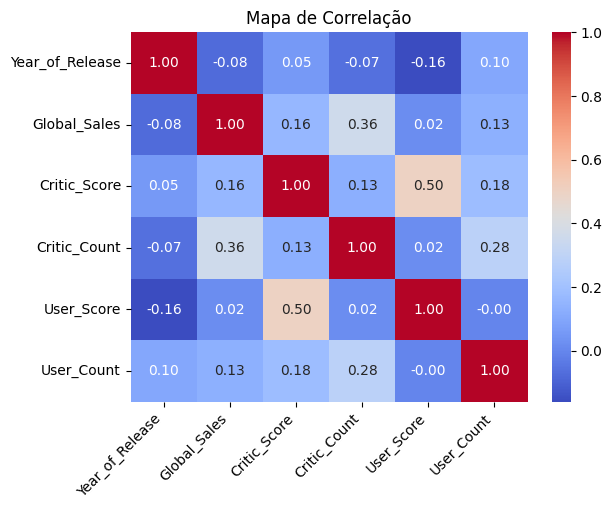

In [13]:
matriz_de_correlacao = games.corr(numeric_only=True)
sns.heatmap(data = matriz_de_correlacao, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Mapa de Correlação')
plt.xticks(rotation=45, ha = 'right')
plt.show()

Interpretação: As variáveis mais correlatas de acordo com o gráfico gerado são a nota da crítica e a nota dos usuários, o que faz sentido se pensarmos que uma nota da crítica é mais técnica, contando jogabilidade, design e outros fatores que tornam a jogatina mais satisfatória para os usuários, e uma jogabilidade satisfatória resulta em uma nota maior pelos usuários, pela lógica e pelo gráfico de correlação

#### Pergunta b.

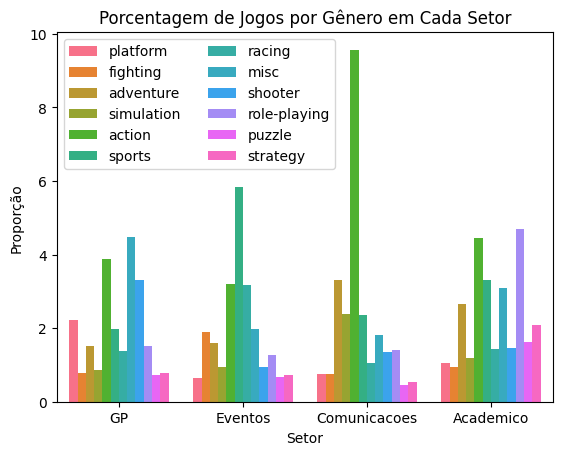

In [14]:
sns.countplot(games, x='Setor', hue='Genre', stat = 'percent', saturation = 10)
plt.ylabel('Proporção')
plt.title('Porcentagem de Jogos por Gênero em Cada Setor')
plt.legend(ncol=2)
plt.show()

Interpretação: Com o gráfico podemos tirar que o gênero de ação está pelo menos no top 2 dos que mais aparecem para cada setor, e tendo uma representação expressiva no caso do setor de comunicações. Dessa forma **o gênero de ação é com certeza o que mais se destaca**, com uma menção aos gêneros variados, esportes e role-playing, que são os de maior destaque nos setores de GP, Eventos e Academico, respectivamente

#### Pergunta c.

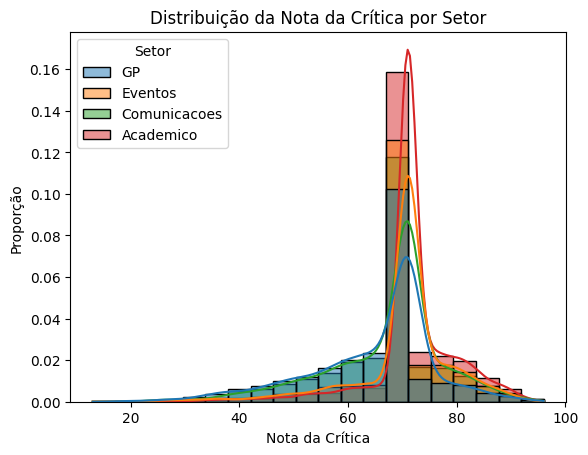

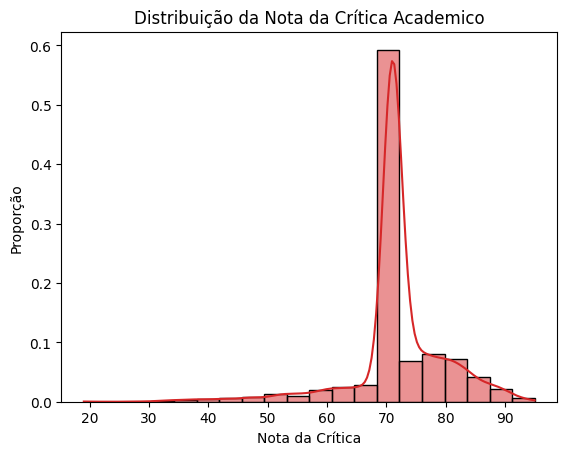

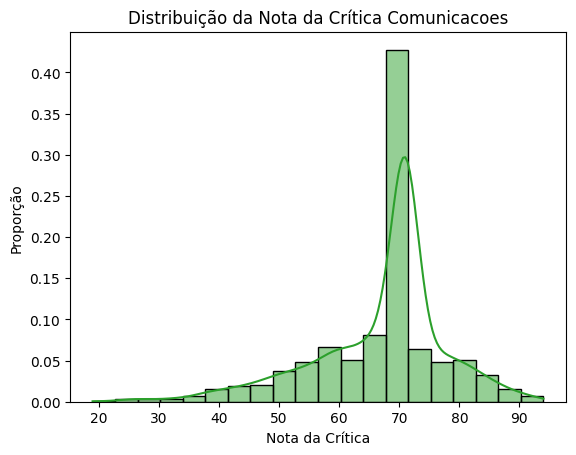

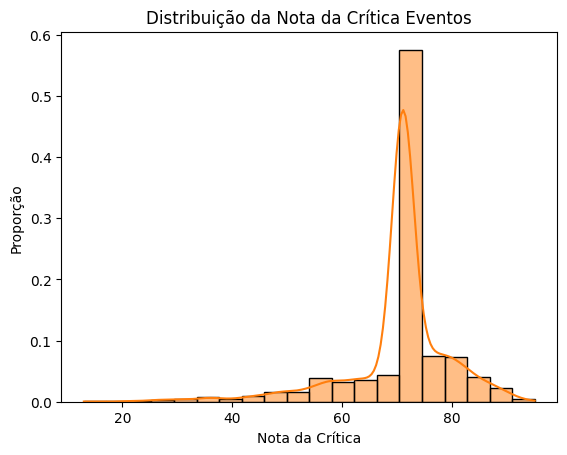

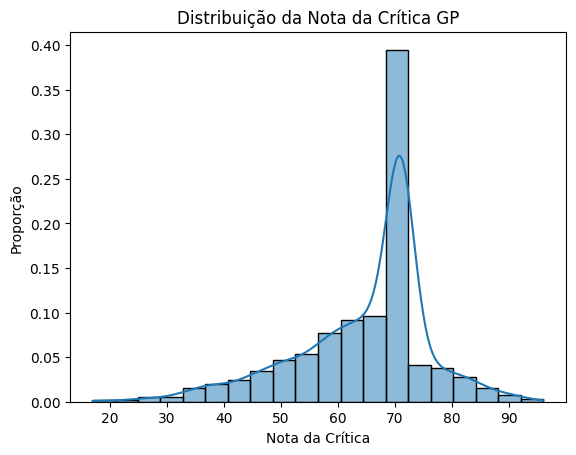

In [15]:
sns.histplot(data = games, x = 'Critic_Score', hue = 'Setor', bins = 20, element='bars', stat = 'proportion', multiple = 'layer', kde = True)
plt.xlabel('Nota da Crítica')
plt.ylabel('Proporção')
plt.title('Distribuição da Nota da Crítica por Setor')
plt.show()
sns.histplot(data = games[games['Setor'] == 'Academico'], x = 'Critic_Score', bins = 20, element='bars', stat = 'proportion', kde = True, color = '#d62728')
plt.xlabel('Nota da Crítica')
plt.ylabel('Proporção')
plt.title('Distribuição da Nota da Crítica Academico')
plt.show()
sns.histplot(data = games[games['Setor'] == 'Comunicacoes'], x = 'Critic_Score', bins = 20, element='bars', stat = 'proportion', kde = True, color = '#2ca02c')
plt.xlabel('Nota da Crítica')
plt.ylabel('Proporção')
plt.title('Distribuição da Nota da Crítica Comunicacoes')
plt.show()
sns.histplot(data = games[games['Setor'] == 'Eventos'], x = 'Critic_Score', bins = 20, element='bars', stat = 'proportion', kde = True, color = '#ff7f0e')
plt.xlabel('Nota da Crítica')
plt.ylabel('Proporção')
plt.title('Distribuição da Nota da Crítica Eventos')
plt.show()
sns.histplot(data = games[games['Setor'] == 'GP'], x = 'Critic_Score', bins = 20, element='bars', stat = 'proportion', kde = True, color = '#1f77b4')
plt.xlabel('Nota da Crítica')
plt.ylabel('Proporção')
plt.title('Distribuição da Nota da Crítica GP')
plt.show()

Interpretação: Com base nesses gráficos vemos que a distribuição dessa variável **não varia** entre os setores do Hype, já que vemos que em todos se concentram perto no valor 70 e seus arredores, em todos os setores. Portanto variar o setor não gerou uma variação significativa na distribuição do "Critic_Score", apenas uma pequena tendência do academico ter mais afinidade com jogos de nota da crítica mais alta em comparação com GP, que emgloba jogos que tem uma nota mais baixa também

#### Pergunta d.

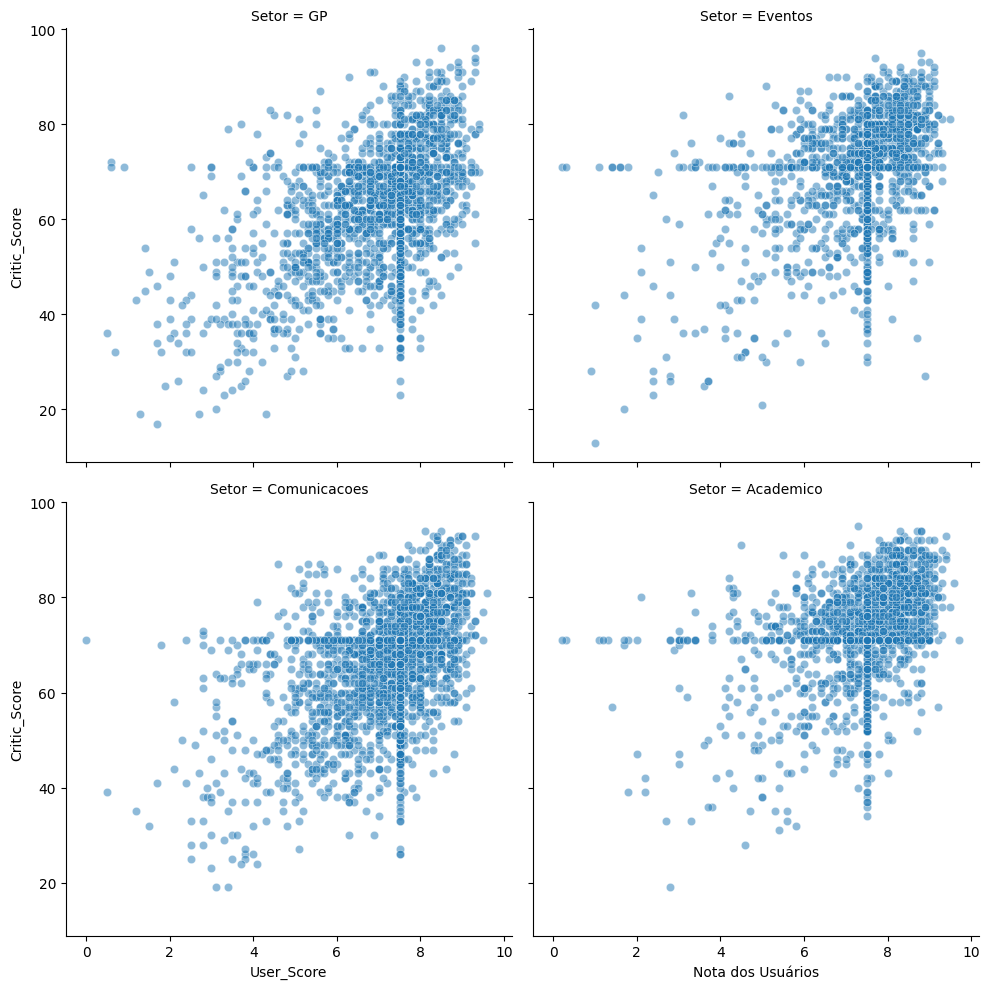

In [16]:
sns.relplot(data=games, x='User_Score', y='Critic_Score', col='Setor', col_wrap=2, alpha=0.5)
plt.xlabel('Nota dos Usuários')
plt.ylabel('Nota da Crítica')
plt.show()

Interpretação: Considerando essas duas variáveis (nota da crítica e nota dos usuários) **é possível distinguir padrões entre os setores**, pois claramente há uma aglomeração maior de valores dos setores Acadêmico e Eventos na região acima de 70 no eixo y (nota da crítica) e acima de 6 no eixo x (nota dos usuários) em relação aos setores de GP e Comunicações. Dessa forma conseguimos ver que os setores **Acadêmico e Eventos** possuem uma afinidade maior com jogos com notas da crítica **acima de 70** e notas dos usuários **acima de 6**, já **Comunicações e GP** possuem **dados muitos espalhados**, mostrando que esses valores não inlfuenciam muito para esses setores

#### Pergunta e.

In [17]:
games.groupby('Sales_Category')[['User_Score', 'Critic_Score']].describe()

User_Score                                               \
                    count      mean       std  min  25%  50%  75%  max   
Sales_Category                                                           
High               3885.0  7.268417  1.157648  0.0  7.0  7.5  7.9  9.6   
Low                3856.0  7.277593  1.039194  0.2  7.5  7.5  7.5  9.7   
Medium             3597.0  7.187795  1.225219  0.2  7.2  7.5  7.5  9.6   

               Critic_Score                                                \
                      count       mean        std   min   25%   50%   75%   
Sales_Category                                                              
High                 3871.0  70.422113  10.466092  23.0  67.0  71.0  77.0   
Low                  3857.0  68.047187   9.785265  13.0  69.0  71.0  71.0   
Medium               3610.0  67.260388  10.968168  17.0  63.0  71.0  71.0   

                      
                 max  
Sales_Category        
High            96.0  
Low             94.0  
Medium          96.0

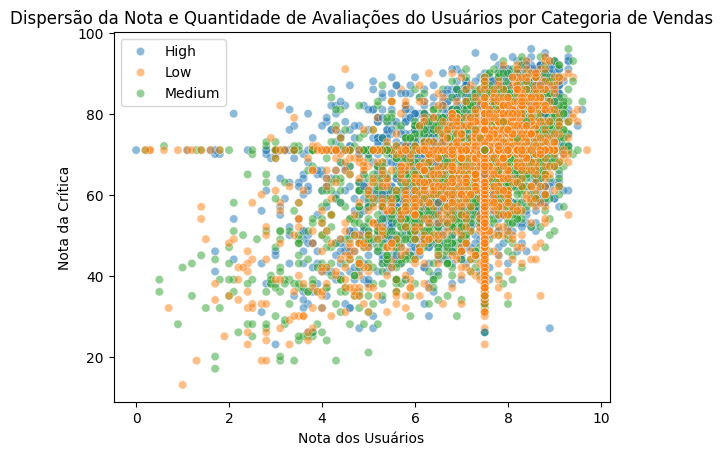

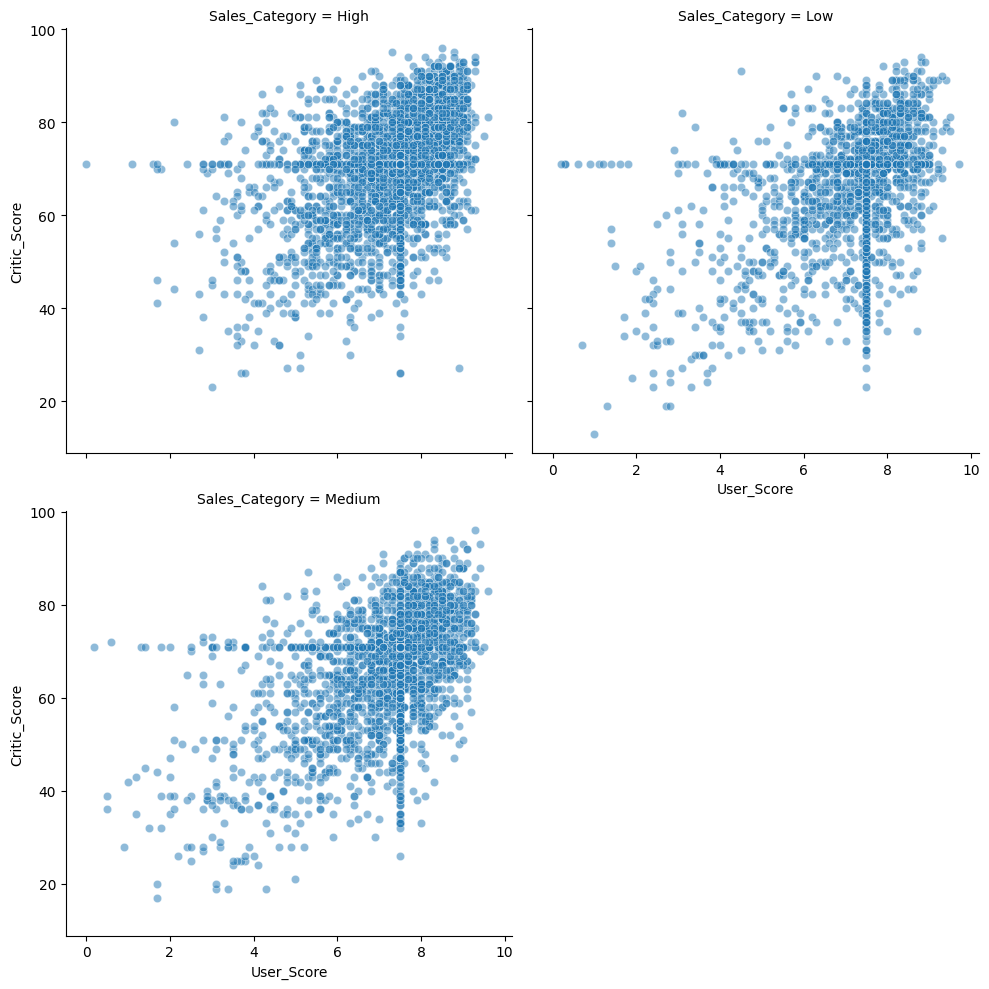

In [18]:
sns.scatterplot(data=games, y = 'Critic_Score', x = 'User_Score', hue='Sales_Category', alpha = 0.5)
plt.xlabel('Nota dos Usuários')
plt.ylabel('Nota da Crítica')
plt.legend(title_fontsize = 'small')
plt.title('Dispersão da Nota e Quantidade de Avaliações do Usuários por Categoria de Vendas')
plt.show()
sns.relplot(data=games, x='User_Score', y='Critic_Score', col='Sales_Category', col_wrap=2, alpha=0.5)
plt.show()

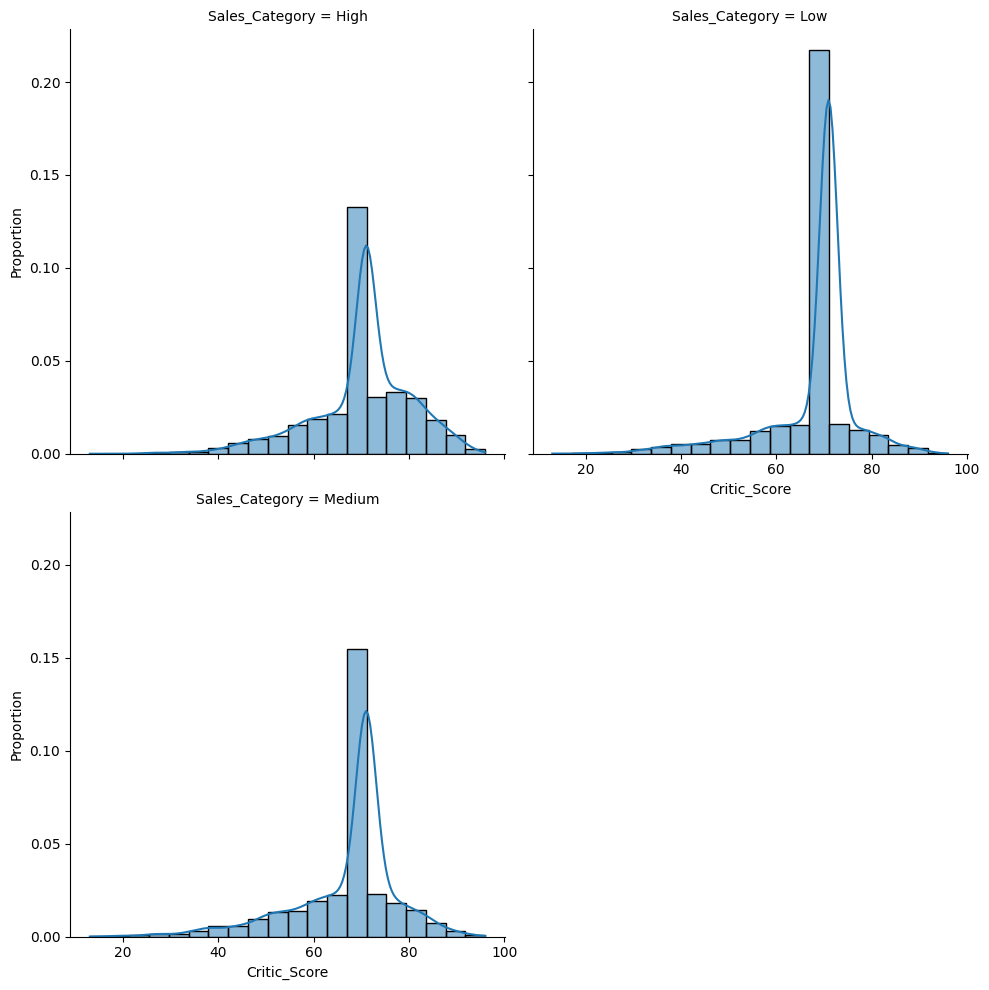

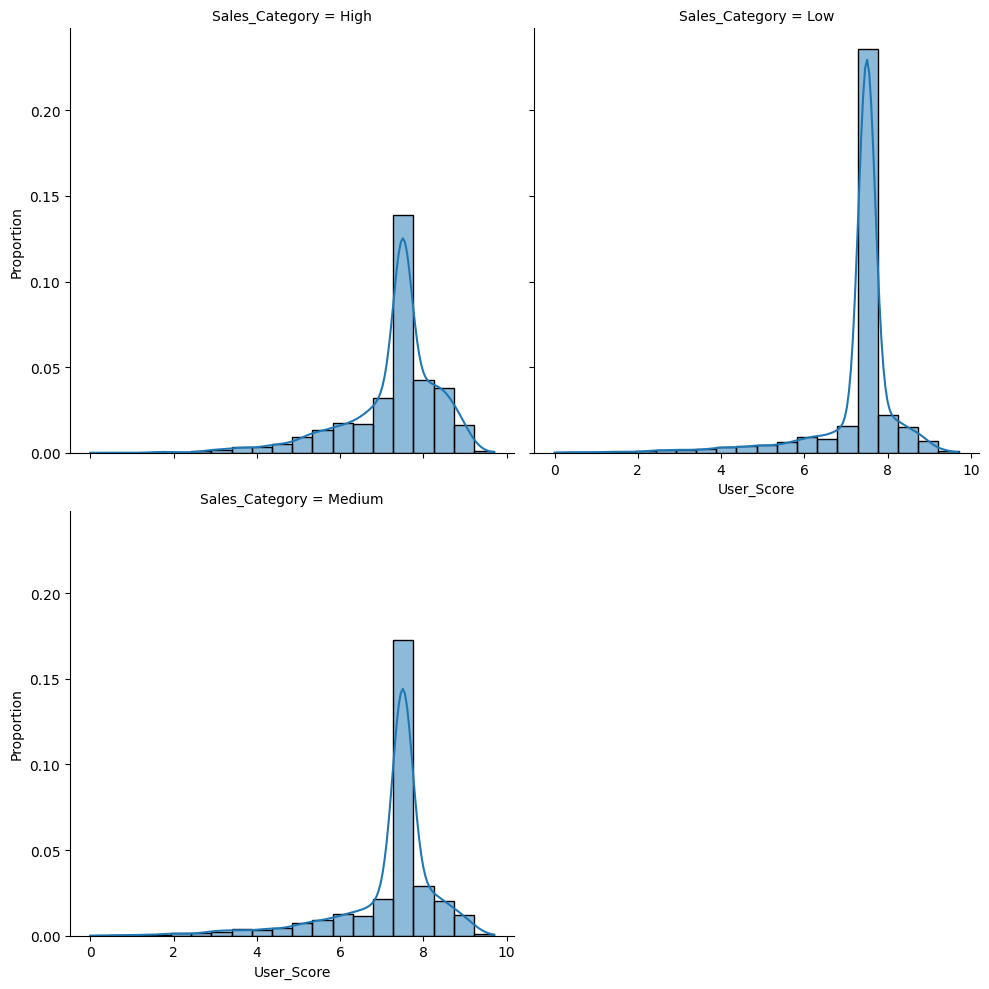

In [19]:
sns.displot(data=games, x='Critic_Score', col='Sales_Category', bins=20,
            element='bars', stat='proportion', kde=True, col_wrap=2)
plt.show()

sns.displot(data=games, x='User_Score', col='Sales_Category', bins=20,
            element='bars', stat='proportion', kde=True, col_wrap=2)
plt.show()

Interpretação: Com base tanto nos gráficos de dispersão quanto nos histogramas, podemos ver que quanto mais baixa a categoria de vendas, mais aglomeradas nas modas e médias das notas da crítica e dos usuários, mostrando que, quanto mais baixa a categoria de vendas de um jogo, mais mediana é sua nota. Portanto **sim** existe alguma relação entre o nível de vendas (Sales_Category) e as avaliações (Critic_Score ou User_Score)

### **Seção 3: Preparação de dados**

Antes de implementar o seu modelo de machine learning, faça o pré-processamento necessário para os seus dados. Tópicos importantes a serem resolvidos nessa seção são:

- Tratamento de dados nulos
- Normalização de variáveis numéricas
- Transformação de variáveis categoricas em numéricas
- Seleção de features

Não necessáriamente os tópicos acima devem ser resolvidos. Pode ser que o algoritmo de machine learning que você escolha não necessite dos tratamentos acima para funcionar ou para melhorar o desempenho. Porém, caso fosse necessário e você não realizou o tratamento, será descontado pontos.

Além dos tópicos acima, faça os tratamentos que julgar necessário.

#### Dados nulos

In [20]:
#identificar onde estão os dados nulos
games.isnull().sum()
(games['Critic_Score'].isnull() & games['User_Score'].isnull()).sum()

#Tratando esses dados nulos
#Como 'Critic_Score' e 'User_Score' possuem uma alta correlação, caso só um deles esteja faltante, copiamos o valor do outro,
#tomando cuidado com as diferentes amplitudes das notas, dos usuários de 0 a 10 e da crítica de 0 a 100
games['Critic_Score'] = games['Critic_Score'].fillna(games['User_Score'] * 10)
games['User_Score'] = games['User_Score'].fillna(games['Critic_Score'] / 10)
#Tratando casos em que as duas variáveis são nulas, nesse caso usando a mediana agrupada dentro do mesmo gênero e plataforma
#do jogo, visando tornar o mais condizente possível e evitando métricas que sejam muito afetadas por outliers
games['Critic_Score'] = games['Critic_Score'].fillna(games.groupby(['Genre', 'Platform'])['Critic_Score'].transform('median'))
games['User_Score'] = games['User_Score'].fillna(games.groupby(['Genre', 'Platform'])['User_Score'].transform('median'))
games.isnull().sum()

,0
Name,0
Platform,0
Year_of_Release,0
Genre,0
Publisher,0
Global_Sales,0
Critic_Score,0
Critic_Count,0
User_Score,0
User_Count,0


#### One hot encoding

In [21]:
### Seu código

#### Normalização

In [22]:
### Seu código

#### Seleção de features

In [23]:
### Seu código

### **Seção 4: Aplicação e Otimização do modelo**

Nessa seção, você deverá criar, treinar e testar um classificador que prediz o setor do Hype com base nas características dos jogos.

Para isso você deverá:

- Dividir o conjunto em treino e teste.
- Escolher um algoritmo de machine learning. Exemplos: Random Forest, KNN, Decision Tree, MLP.
- Treinar o modelo com os dados de treino.
- Predizer a label a partir das features de teste.
- Utilizar algum método para ajustar os hiperparâmetros. Discuta as melhorias obtidas.

#### Separação Treino e Teste

In [24]:
### Seu código

#### Aplicação do modelo

In [25]:
### Seu código

#### Hyperparameter Tuning

In [26]:
### Seu código

#### **Seção 5: Avaliação**

Avaliar o desempenho do modelo é crucial. Utilize pelo menos 3 métricas para essa avaliação, detalhando-as. O que as métricas indicam sobre o desempenho do seu modelo? Dica de métricas: acurácia e revocação.

In [27]:
### Seu código